<a href="https://colab.research.google.com/github/Eshachatterjee01/data_science_all/blob/main/Ada_Boosting_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [ ]:
df = pd.DataFrame()

In [ ]:

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [ ]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

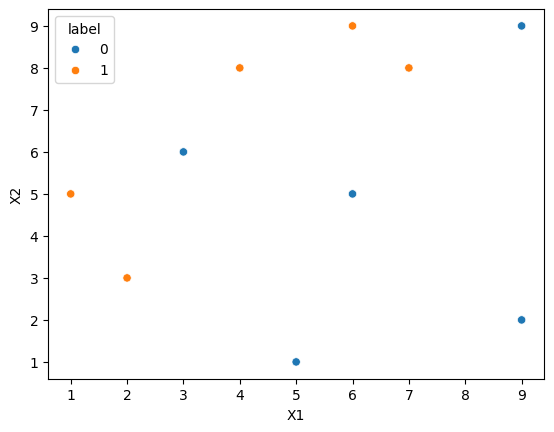

In [ ]:
import seaborn as sns
sns.scatterplot(x=df['X1'], y=df['X2'],hue=df['label'])

In [ ]:
df.shape

(10, 3)

In [ ]:
df.shape[0]

10

Step 1 - Initialize Sample Weights

In [ ]:
df['weights'] = 1/df.shape[0]

In [ ]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


Step 2: Train Weak Learner

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [ ]:
x = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [ ]:
#Train the model
dt1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

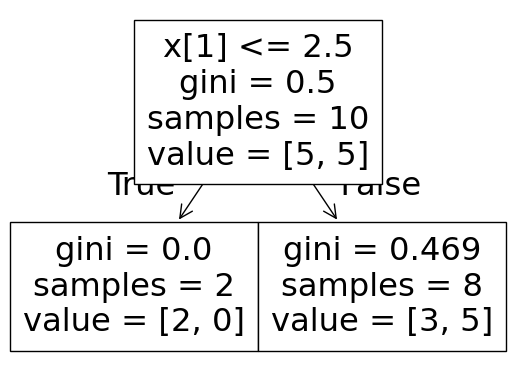

In [ ]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

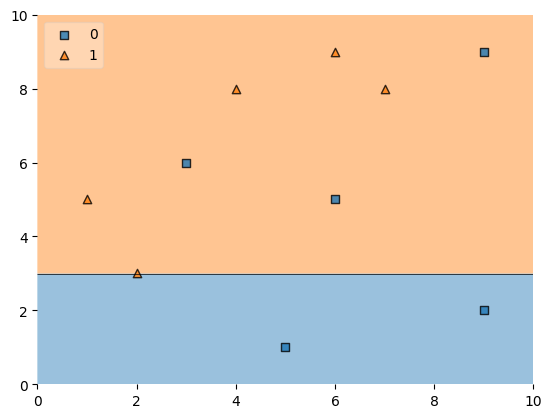

In [ ]:
plot_decision_regions(x,y,clf=dt1,legend=2) #so its making 3 incorrect predictions

In [ ]:
df['y_pred'] = dt1.predict(x)

In [ ]:
#so we can see its making 3 mistakes or missclassification
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


Step 3: Calculate Error of Weak Learner

Error = the sum of the weights of the misclassified samples.
means here that will be 0.1+0.1+0.1 = 0.3

In [ ]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error))

Step 4: Compute the Model Weight (Alpha)

In [ ]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

Step 5: Update Sample Weights


In [ ]:
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [ ]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [ ]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [ ]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [ ]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [ ]:
df['normalized_weights'].sum()

np.float64(1.0)

Now will create the Range

In [ ]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [ ]:
df['cumsum_lower'] = df['cumsum_upper']-df['normalized_weights']


In [ ]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [ ]:
df.columns

Index(['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights',
       'normalized_weights', 'cumsum_upper', 'cumsum_lower'],
      dtype='object')

In [ ]:
df[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights','normalized_weights', 'cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.071475,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.166559,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.071475,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.071475,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.071475,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.166559,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.071475,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.166559,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.071475,0.928525,1.000000


This is the Upsampling process

In [ ]:
def create_new_dataset(df):
  indices=[]

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper']>a and a>row['cumsum_lower']:
        indices.append(index)
  return indices

In [ ]:
index_values = create_new_dataset(df)
index_values

[4, 6, 0, 2, 2, 9, 7, 6, 5, 8]

We will create new dataset with the value of the index of the row ->index_values
and column we will take 0,1,2,3 till Weights

In [ ]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [ ]:
second_df

,X1,X2,label,weights
4,5,1,0,0.1
6,6,5,0,0.1
0,1,5,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1
9,9,2,0,0.1
7,7,8,1,0.1
6,6,5,0,0.1
5,6,9,1,0.1
8,9,9,0,0.1


Now we will create 2nd Decision Tree

In [ ]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [ ]:
x = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [ ]:
x

array([[5, 1],
       [6, 5],
       [1, 5],
       [3, 6],
       [3, 6],
       [9, 2],
       [7, 8],
       [6, 5],
       [6, 9],
       [9, 9]])

In [ ]:
y

array([0, 0, 1, 0, 0, 0, 1, 0, 1, 0])

In [ ]:
dt2.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.625, 0.5, '  False')]

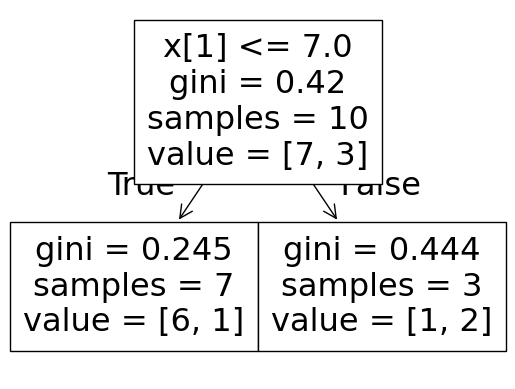

In [ ]:
plot_tree(dt2)

<Axes: >

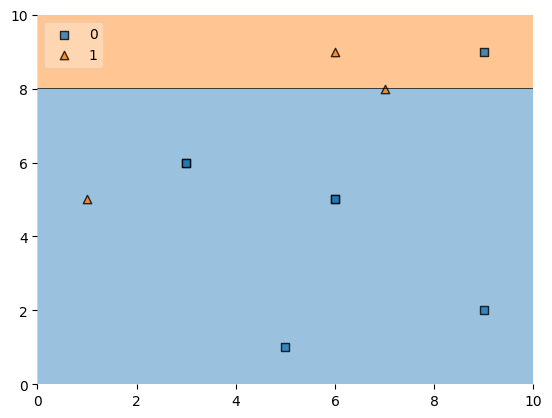

In [ ]:
plot_decision_regions(x,y,clf=dt2,legend=2)

In [ ]:
second_df['y_pred']=dt2.predict(x)

In [ ]:
second_df

,X1,X2,label,weights,y_pred
4,5,1,0,0.1,0
6,6,5,0,0.1,0
0,1,5,1,0.1,0
2,3,6,0,0.1,0
2,3,6,0,0.1,0
9,9,2,0,0.1,0
7,7,8,1,0.1,1
6,6,5,0,0.1,0
5,6,9,1,0.1,1
8,9,9,0,0.1,1


Calculating model Weight Alpha2
so our new model second_df misclassifying 2 sample thats why error value will be--> 0.1+0.1 = 0.2

In [ ]:
alpha2 = calculate_model_weight(0.2)

In [ ]:
alpha2

np.float64(0.6931471805599453)

Now again we will update the weights.this time alpha value will be 0.69

In [ ]:
def update_row_weights(row,alpha=0.69):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [ ]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [ ]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
4,5,1,0,0.1,0,0.050158
6,6,5,0,0.1,0,0.050158
0,1,5,1,0.1,0,0.199372
2,3,6,0,0.1,0,0.050158
2,3,6,0,0.1,0,0.050158
9,9,2,0,0.1,0,0.050158
7,7,8,1,0.1,1,0.050158
6,6,5,0,0.1,0,0.050158
5,6,9,1,0.1,1,0.050158
8,9,9,0,0.1,1,0.199372


In [ ]:
second_df['updated_weights'].sum()

np.float64(0.800003961901461)

we have to make the sum 1 thats why we will normalized it

In [ ]:
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [ ]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
4,5,1,0,0.1,0,0.050158,0.062697
6,6,5,0,0.1,0,0.050158,0.062697
0,1,5,1,0.1,0,0.199372,0.249213
2,3,6,0,0.1,0,0.050158,0.062697
2,3,6,0,0.1,0,0.050158,0.062697
9,9,2,0,0.1,0,0.050158,0.062697
7,7,8,1,0.1,1,0.050158,0.062697
6,6,5,0,0.1,0,0.050158,0.062697
5,6,9,1,0.1,1,0.050158,0.062697
8,9,9,0,0.1,1,0.199372,0.249213


In [ ]:
second_df['normalized_weights'].sum()

np.float64(1.0)

Now again will create the Range

In [ ]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])

In [ ]:
second_df['cumsum_lower'] = second_df['cumsum_upper']-second_df['normalized_weights']

In [ ]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
4,5,1,0,0.1,0,0.050158,0.062697,0.062697,0.000000
6,6,5,0,0.1,0,0.050158,0.062697,0.125393,0.062697
0,1,5,1,0.1,0,0.199372,0.249213,0.374607,0.125393
2,3,6,0,0.1,0,0.050158,0.062697,0.437303,0.374607
2,3,6,0,0.1,0,0.050158,0.062697,0.500000,0.437303
9,9,2,0,0.1,0,0.050158,0.062697,0.562697,0.500000
7,7,8,1,0.1,1,0.050158,0.062697,0.625393,0.562697
6,6,5,0,0.1,0,0.050158,0.062697,0.688090,0.625393
5,6,9,1,0.1,1,0.050158,0.062697,0.750787,0.688090
8,9,9,0,0.1,1,0.199372,0.249213,1.000000,0.750787


In [ ]:
second_df.columns

Index(['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights',
       'normalized_weights', 'cumsum_upper', 'cumsum_lower'],
      dtype='object')

In [ ]:
second_df[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights','normalized_weights', 'cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_lower,cumsum_upper
4,5,1,0,0.1,0,0.050158,0.062697,0.000000,0.062697
6,6,5,0,0.1,0,0.050158,0.062697,0.062697,0.125393
0,1,5,1,0.1,0,0.199372,0.249213,0.125393,0.374607
2,3,6,0,0.1,0,0.050158,0.062697,0.374607,0.437303
2,3,6,0,0.1,0,0.050158,0.062697,0.437303,0.500000
9,9,2,0,0.1,0,0.050158,0.062697,0.500000,0.562697
7,7,8,1,0.1,1,0.050158,0.062697,0.562697,0.625393
6,6,5,0,0.1,0,0.050158,0.062697,0.625393,0.688090
5,6,9,1,0.1,1,0.050158,0.062697,0.688090,0.750787
8,9,9,0,0.1,1,0.199372,0.249213,0.750787,1.000000


In [ ]:
def create_new_dataset(second_df):
  indices=[]

  for i in range(second_df.shape[0]):
    a = np.random.random()
    for index,row in second_df.iterrows():
      if row['cumsum_upper']>a and a>row['cumsum_lower']:
        indices.append(index)
  return indices

In [ ]:
index_values = create_new_dataset(second_df)
index_values

[0, 9, 6, 8, 6, 8, 8, 8, 8, 6]

In [ ]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [ ]:
third_df

,X1,X2,label,weights
4,5,1,0,0.1
8,9,9,0,0.1
7,7,8,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
5,6,9,1,0.1
5,6,9,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1


Now we will create 3rd Decision Tree

In [ ]:
dt3 = DecisionTreeClassifier(max_depth=1)

In [ ]:
x = third_df.iloc[:,0:2].values
y = third_df.iloc[:,2].values

In [ ]:
dt3.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 4.5\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.625, 0.5, '  False')]

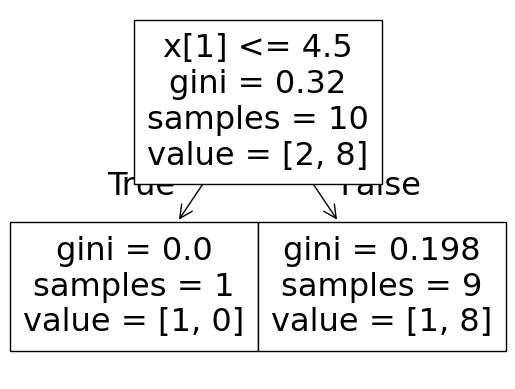

In [ ]:
plot_tree(dt3)

<Axes: >

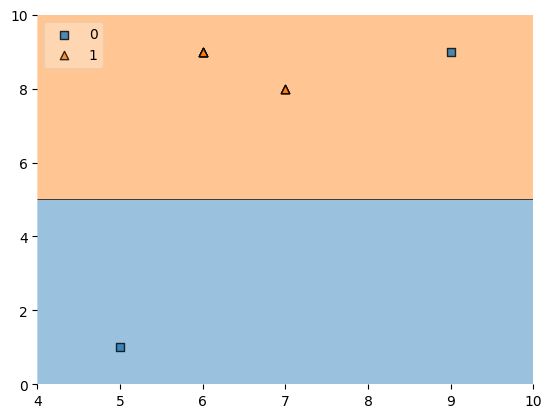

In [ ]:
plot_decision_regions(x,y,clf=dt3,legend=2)

In [ ]:
third_df['y_pred']=dt3.predict(x)

In [ ]:
third_df

,X1,X2,label,weights,y_pred
4,5,1,0,0.1,0
8,9,9,0,0.1,1
7,7,8,1,0.1,1
5,6,9,1,0.1,1
7,7,8,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
7,7,8,1,0.1,1


In [ ]:
alpha3 = calculate_model_weight(0.1)

In [ ]:
alpha3

np.float64(1.0986122886681098)

The process we have to do untill the error become 0

In [ ]:
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [ ]:
third_df['updated_weights'] = third_df.apply(update_row_weights,axis=1)

In [ ]:
third_df['updated_weights'].sum()

np.float64(0.6000222515923667)

In [ ]:
third_df['normalized_weights'] = third_df['updated_weights']/third_df['updated_weights'].sum()

In [ ]:
third_df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [ ]:
third_df['cumsum_upper'] = np.cumsum(third_df['normalized_weights'])

In [ ]:
third_df['cumsum_lower'] = third_df['cumsum_upper']-third_df['normalized_weights']

In [ ]:
third_df[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights','normalized_weights', 'cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_lower,cumsum_upper
4,5,1,0,0.1,0,0.033622,0.056034,0.000000,0.056034
8,9,9,0,0.1,1,0.297427,0.495694,0.056034,0.551728
7,7,8,1,0.1,1,0.033622,0.056034,0.551728,0.607762
5,6,9,1,0.1,1,0.033622,0.056034,0.607762,0.663796
7,7,8,1,0.1,1,0.033622,0.056034,0.663796,0.719830
5,6,9,1,0.1,1,0.033622,0.056034,0.719830,0.775864
5,6,9,1,0.1,1,0.033622,0.056034,0.775864,0.831898
5,6,9,1,0.1,1,0.033622,0.056034,0.831898,0.887932
5,6,9,1,0.1,1,0.033622,0.056034,0.887932,0.943966
7,7,8,1,0.1,1,0.033622,0.056034,0.943966,1.000000


In [ ]:
def create_new_dataset(third_df):
  indices=[]

  for i in range(third_df.shape[0]):
    a = np.random.random()
    for index,row in third_df.iterrows():
      if row['cumsum_upper']>a and a>row['cumsum_lower']:
        indices.append(index)
  return indices

In [ ]:
index_values = create_new_dataset(third_df)
index_values

[8, 7, 8, 8, 8, 8, 7, 8, 8, 7]

In [ ]:
fourth_df = third_df.iloc[index_values,[0,1,2,3]]

In [ ]:
dt4 = DecisionTreeClassifier(max_depth=1)


In [ ]:
x = fourth_df.iloc[:,0:2].values
y = fourth_df.iloc[:,2].values

In [ ]:
dt4.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.5, 'gini = 0.0\nsamples = 10\nvalue = 1.0')]

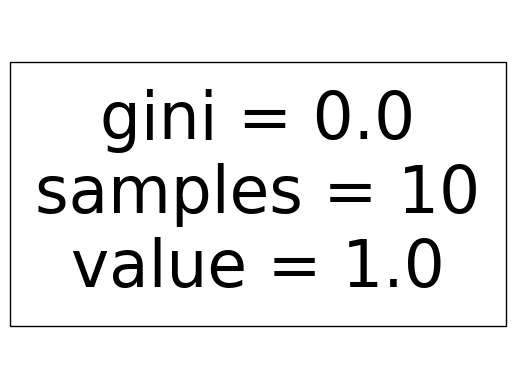

In [ ]:
plot_tree(dt4)

<Axes: >

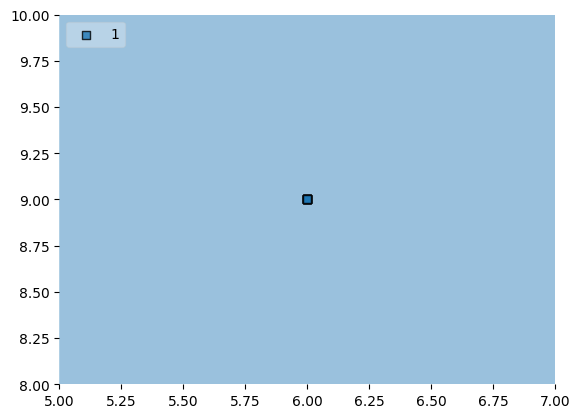

In [ ]:
plot_decision_regions(x,y,clf=dt4,legend=2)

In [ ]:
fourth_df['y_pred']=dt4.predict(x)

In [ ]:
fourth_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1


if error is zero then that alpha function will not work that time we have to add minimal number like 0.00001 with error
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error+0.00001))  like this

In [ ]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error+0.00001))

In [ ]:
alpha4 = calculate_model_weight(0)

In [ ]:
alpha4

np.float64(5.756462732485114)

In [ ]:
print(alpha1,alpha2,alpha3,alpha4)

0.42364893019360184 0.6931471805599453 1.0986122886681098 5.756462732485114


Prediction
we wil check with existing row first
0	1	5	1

In [ ]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [ ]:
dt2.predict(query)

array([0])

In [ ]:
dt3.predict(query)

array([1])

In [ ]:
dt4.predict(query)

array([1])

for boosting we have to take 0 as -1.  
1 for 1  
-1 for 0

In [ ]:
alpha1*(1) + alpha2*(-1) + alpha3*(1)+alpha4*(1)

np.float64(6.585576770786881)

In [ ]:
np.sign(6.585)

np.float64(1.0)

As the sign is 1 so its correctly predicted.

Now will predict the existing row 3	6	0

In [ ]:
query = np.array([3,6]).reshape(1,2)
dt1.predict(query)

array([1])

In [ ]:
dt2.predict(query)

array([0])

In [ ]:
dt3.predict(query)

array([1])

In [ ]:
dt4.predict(query)

array([1])

In [ ]:
alpha1*(1) + alpha2*(-1) + alpha3*(1)+alpha4*(1)

np.float64(6.585576770786881)

In [ ]:
np.sign(6.585)

np.float64(1.0)